In [1]:
# Celda 1: Setup y librerías
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error
import gc
import os
import warnings
warnings.filterwarnings('ignore')

# Configuración visual (manteniendo el estilo claro y profesional)
sns.set_palette(["#6a0dad", "#2ecc71", "#e74c3c", "#3498db"])
plt.style.use('ggplot')

# --- CONFIGURACIÓN DEL PIPELINE ---
# Para no colapsar la RAM, empezamos a cargar desde el día 1400 (aprox. 1.5 años de datos)
START_DAY = 1400
END_DAY = 1941
VAL_DAYS = 28
ESTADOS = ['CA', 'TX', 'WI']

# Crear carpeta para guardar los modelos
if not os.path.exists('modelos_m5'):
    os.makedirs('modelos_m5')

print("Configuración inicializada. Estados a procesar:", ESTADOS)

Configuración inicializada. Estados a procesar: ['CA', 'TX', 'WI']


In [2]:
# Celda 2: Lógica de preparación de datos por estado
def preparar_datos_estado(estado):
    print(f"\n[{estado}] 1. Cargando y filtrando ventas...")
    id_cols = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
    day_cols = [f'd_{i}' for i in range(START_DAY, END_DAY + 1)]
    
    # Cargar y filtrar por el estado actual
    df_sales = pd.read_csv('sales_train_evaluation.csv', usecols=id_cols + day_cols)
    df_sales = df_sales[df_sales['state_id'] == estado].reset_index(drop=True)
    
    print(f"[{estado}] 2. Optimizando tipos y aplicando Melt...")
    for col in id_cols:
        df_sales[col] = df_sales[col].astype('category')
    for col in day_cols:
        df_sales[col] = df_sales[col].astype(np.int16)
        
    df = pd.melt(df_sales, id_vars=id_cols, var_name='d', value_name='sold')
    del df_sales
    gc.collect()
    
    df['d'] = df['d'].apply(lambda x: int(x.split('_')[1])).astype(np.int16)
    
    print(f"[{estado}] 3. Cruzando con Calendario...")
    calendar = pd.read_csv('calendar.csv')
    calendar['d'] = calendar['d'].apply(lambda x: int(x.split('_')[1])).astype(np.int16)
    calendar = calendar[calendar['d'] >= START_DAY]
    
    # Seleccionamos la columna SNAP correcta según el estado (ej. snap_CA)
    snap_col = f'snap_{estado}'
    cal_cols = ['d', 'wm_yr_wk', 'wday', 'month', 'year', snap_col]
    
    df = pd.merge(df, calendar[cal_cols], on='d', how='left')
    del calendar
    gc.collect()
    
    print(f"[{estado}] 4. Cruzando con Precios...")
    prices = pd.read_csv('sell_prices.csv')
    tiendas_del_estado = df['store_id'].unique()
    prices = prices[prices['store_id'].isin(tiendas_del_estado)]
    prices['sell_price'] = prices['sell_price'].astype(np.float32)
    
    df = pd.merge(df, prices, on=['store_id', 'item_id', 'wm_yr_wk'], how='left')
    del prices
    gc.collect()
    
    print(f"[{estado}] 5. Generando Lags Temporales (Feature Engineering)...")
    # Ordenar estrictamente por tienda, item y día para que el shift sea correcto
    df = df.sort_values(['store_id', 'item_id', 'd']).reset_index(drop=True)
    # Lag 28 porque tenemos que predecir a 28 días vista
    df['lag_28'] = df.groupby(['store_id', 'item_id'])['sold'].shift(28)
    
    df.dropna(inplace=True)
    
    return df, snap_col

🚀 INICIANDO PIPELINE PARA: CA

[CA] 1. Cargando y filtrando ventas...
[CA] 2. Optimizando tipos y aplicando Melt...
[CA] 3. Cruzando con Calendario...
[CA] 4. Cruzando con Precios...
[CA] 5. Generando Lags Temporales (Feature Engineering)...
[CA] Dividiendo en Train y Validación...
[CA] Datos de Train: 5854307 filas | Validación: 341488 filas
[CA] Entrenando Modelo XGBoost...
[0]	validation_0-rmse:3.69663	validation_0-mae:1.68600	validation_1-rmse:3.53424	validation_1-mae:1.68393
[100]	validation_0-rmse:2.35017	validation_0-mae:1.10156	validation_1-rmse:2.20928	validation_1-mae:1.15157
[200]	validation_0-rmse:2.28764	validation_0-mae:1.07649	validation_1-rmse:2.17425	validation_1-mae:1.13991
[300]	validation_0-rmse:2.25591	validation_0-mae:1.06273	validation_1-rmse:2.16574	validation_1-mae:1.13512
[400]	validation_0-rmse:2.23849	validation_0-mae:1.05384	validation_1-rmse:2.16020	validation_1-mae:1.13243
[500]	validation_0-rmse:2.22074	validation_0-mae:1.04627	validation_1-rmse:2.15885	

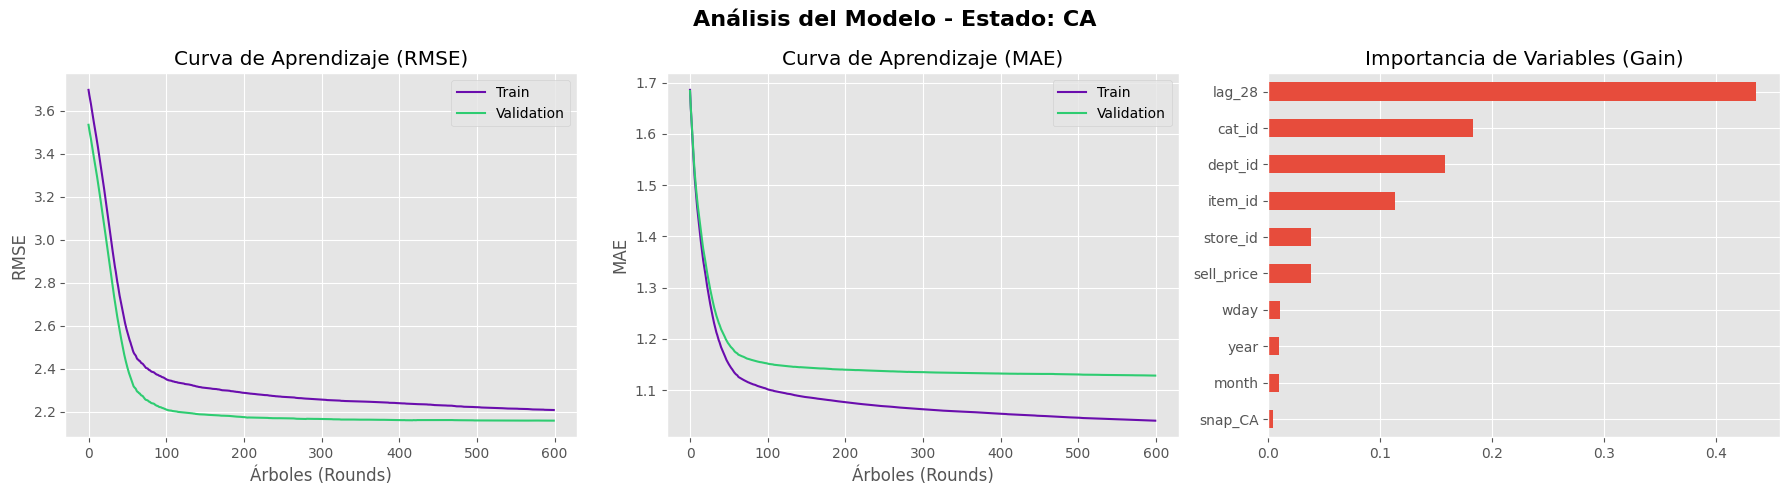

[CA] Finalizado y memoria liberada.


🚀 INICIANDO PIPELINE PARA: TX

[TX] 1. Cargando y filtrando ventas...
[TX] 2. Optimizando tipos y aplicando Melt...
[TX] 3. Cruzando con Calendario...
[TX] 4. Cruzando con Precios...
[TX] 5. Generando Lags Temporales (Feature Engineering)...
[TX] Dividiendo en Train y Validación...
[TX] Datos de Train: 4429135 filas | Validación: 256116 filas
[TX] Entrenando Modelo XGBoost...
[0]	validation_0-rmse:3.45436	validation_0-mae:1.48547	validation_1-rmse:3.47184	validation_1-mae:1.51104
[100]	validation_0-rmse:2.05288	validation_0-mae:0.95872	validation_1-rmse:2.03320	validation_1-mae:1.00280
[200]	validation_0-rmse:1.99715	validation_0-mae:0.93789	validation_1-rmse:1.99656	validation_1-mae:0.99119
[300]	validation_0-rmse:1.97064	validation_0-mae:0.92672	validation_1-rmse:1.98759	validation_1-mae:0.98683
[400]	validation_0-rmse:1.95673	validation_0-mae:0.91938	validation_1-rmse:1.98440	validation_1-mae:0.98367
[500]	validation_0-rmse:1.94245	validation_0-

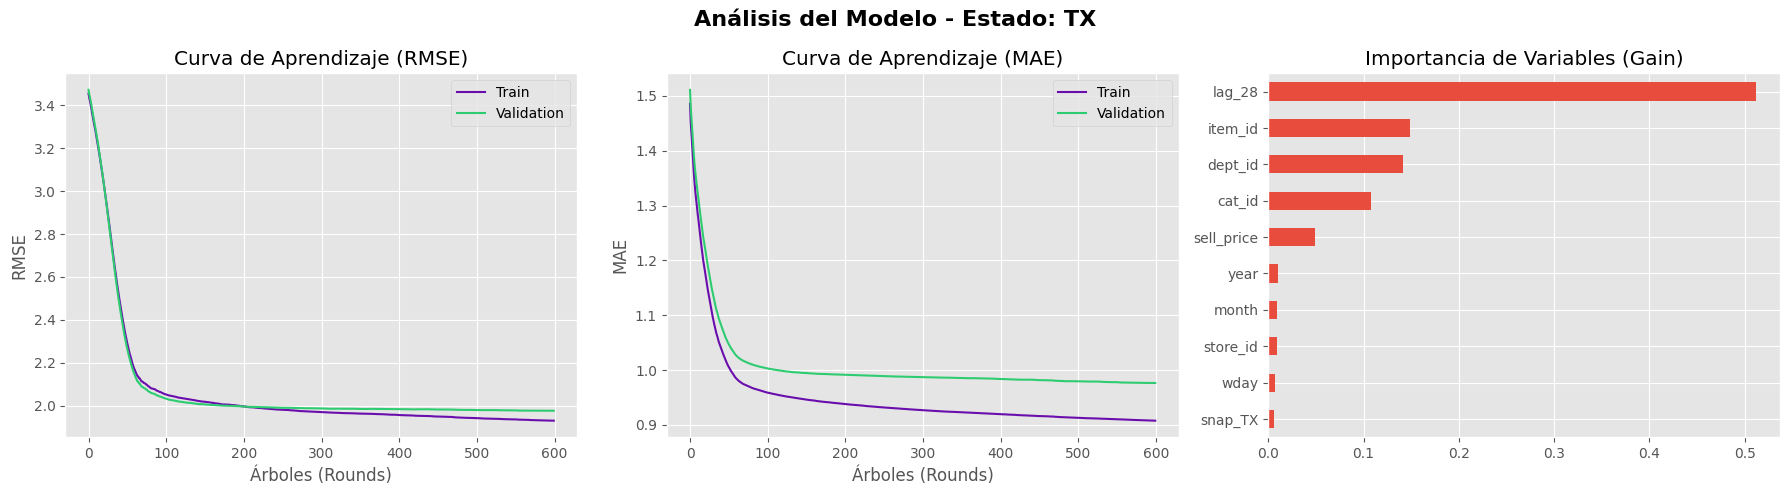

[TX] Finalizado y memoria liberada.


🚀 INICIANDO PIPELINE PARA: WI

[WI] 1. Cargando y filtrando ventas...
[WI] 2. Optimizando tipos y aplicando Melt...
[WI] 3. Cruzando con Calendario...
[WI] 4. Cruzando con Precios...
[WI] 5. Generando Lags Temporales (Feature Engineering)...
[WI] Dividiendo en Train y Validación...
[WI] Datos de Train: 4429736 filas | Validación: 256116 filas
[WI] Entrenando Modelo XGBoost...
[0]	validation_0-rmse:3.45142	validation_0-mae:1.56963	validation_1-rmse:3.87599	validation_1-mae:1.67115
[100]	validation_0-rmse:2.29243	validation_0-mae:1.01891	validation_1-rmse:2.46748	validation_1-mae:1.09900
[200]	validation_0-rmse:2.23851	validation_0-mae:0.99739	validation_1-rmse:2.42242	validation_1-mae:1.09085
[300]	validation_0-rmse:2.20899	validation_0-mae:0.98482	validation_1-rmse:2.40606	validation_1-mae:1.08563
[400]	validation_0-rmse:2.19337	validation_0-mae:0.97701	validation_1-rmse:2.40136	validation_1-mae:1.08231
[500]	validation_0-rmse:2.17602	validation_0-

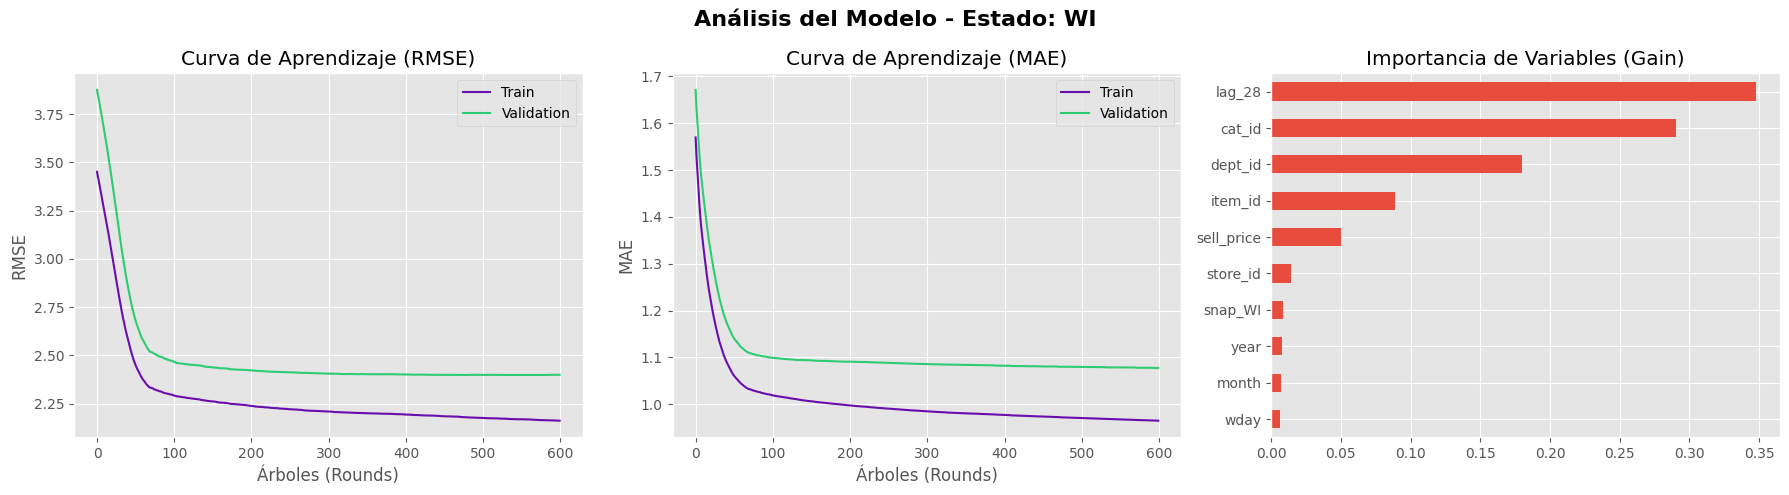

[WI] Finalizado y memoria liberada.


TODO EL PIPELINE COMPLETADO EXITOSAMENTE


In [4]:
# Celda 3: Entrenamiento y Evaluación por Estado

for estado in ESTADOS:
    print("="*60)
    print(f"🚀 INICIANDO PIPELINE PARA: {estado}")
    print("="*60)
    
    # 1. Preparar datos
    df, snap_col = preparar_datos_estado(estado)
    
    cols_texto = ['item_id', 'dept_id', 'cat_id', 'store_id']
    for col in cols_texto:
        df[col] = df[col].astype('category')

    # 2. División Train / Validación (Últimos 28 días)
    print(f"[{estado}] Dividiendo en Train y Validación...")
    d_max = df['d'].max()
    train_mask = df['d'] <= (d_max - VAL_DAYS)
    val_mask = df['d'] > (d_max - VAL_DAYS)
    
    features = ['item_id', 'dept_id', 'cat_id', 'store_id', 
                'sell_price', 'wday', 'month', 'year', snap_col, 'lag_28']
    
    X_train, y_train = df.loc[train_mask, features], df.loc[train_mask, 'sold']
    X_val, y_val = df.loc[val_mask, features], df.loc[val_mask, 'sold']
    
    print(f"[{estado}] Datos de Train: {X_train.shape[0]} filas | Validación: {X_val.shape[0]} filas")
    
    # 3. Configurar y Entrenar XGBoost
    print(f"[{estado}] Entrenando Modelo XGBoost...")
    xgb_params = {
        'objective': 'reg:tweedie',
        'tree_method': 'hist',        
        'enable_categorical': True,  
        'eval_metric': ['rmse', 'mae'],
        'learning_rate': 0.05,
        'max_depth': 8,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'n_estimators': 600,
        'n_jobs': -1,
        'early_stopping_rounds': 30   
    }
    
    model = xgb.XGBRegressor(**xgb_params)
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=100
    )
    
    # 4. Guardar el Modelo
    ruta_modelo = f'modelos_m5/xgb_model_{estado}.json'
    model.save_model(ruta_modelo)
    print(f"[{estado}] Modelo guardado en: {ruta_modelo}")
    
    # 5. Predicciones y Métricas
    preds = model.predict(X_val)
    mae = mean_absolute_error(y_val, preds)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    
    scale = np.mean(np.diff(y_train.values) ** 2)
    rmsse = np.sqrt(mean_squared_error(y_val, preds) / scale) if scale > 0 else 0
    
    print("-" * 40)
    print(f"RESULTADOS {estado}")
    print(f"MAE:   {mae:.4f}")
    print(f"RMSE:  {rmse:.4f}")
    print(f"RMSSE: {rmsse:.4f} (Proxy no ponderado)")
    print("-" * 40)
    
    # 6. Gráficas (Curvas de aprendizaje e Importancia)
    evals_result = model.evals_result()
    epochs = len(evals_result['validation_0']['rmse'])
    x_axis = range(0, epochs)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Análisis del Modelo - Estado: {estado}', fontsize=16, fontweight='bold')
    
    axes[0].plot(x_axis, evals_result['validation_0']['rmse'], label='Train', color='#6a0dad')
    axes[0].plot(x_axis, evals_result['validation_1']['rmse'], label='Validation', color='#2ecc71')
    axes[0].set_title('Curva de Aprendizaje (RMSE)')
    axes[0].set_xlabel('Árboles (Rounds)')
    axes[0].set_ylabel('RMSE')
    axes[0].legend()
    
    axes[1].plot(x_axis, evals_result['validation_0']['mae'], label='Train', color='#6a0dad')
    axes[1].plot(x_axis, evals_result['validation_1']['mae'], label='Validation', color='#2ecc71')
    axes[1].set_title('Curva de Aprendizaje (MAE)')
    axes[1].set_xlabel('Árboles (Rounds)')
    axes[1].set_ylabel('MAE')
    axes[1].legend()
    
    importances = pd.Series(model.feature_importances_, index=features).sort_values()
    importances.plot(kind='barh', ax=axes[2], color='#e74c3c')
    axes[2].set_title('Importancia de Variables (Gain)')
    
    plt.tight_layout()
    plt.show()
    
    # 7. Liberar memoria
    del df, X_train, y_train, X_val, y_val, model
    gc.collect()
    print(f"[{estado}] Finalizado y memoria liberada.\n\n")

print("TODO EL PIPELINE COMPLETADO EXITOSAMENTE")